# Capstone: classification

Music Genre Classification Capstone

  Dataset: 50,000 Spotify songs | 10 genres
  
  Best model: Feedforward Neural Network (ReLU) | AUC: 88.3%

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.chdir("/content/drive/MyDrive/Machine Learning/classification")

Mounted at /content/drive


In [ ]:
import random
random.seed(YOUR_N_NUMBER)
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Perceptron
from sklearn.decomposition import PCA
from sklearn import cluster
from sklearn.metrics import silhouette_score
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix, mean_squared_error, f1_score, \
    matthews_corrcoef, RocCurveDisplay, accuracy_score
from torch import nn, optim
from torch.utils.data import DataLoader, TensorDataset
from imblearn.under_sampling import RandomUnderSampler
from sklearn.manifold import TSNE
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '0' ]

In [4]:
def sklearn_to_df(sklearn_dataset):
    df = pd.DataFrame(sklearn_dataset.data, columns=sklearn_dataset.feature_names)
    df['target'] = pd.Series(sklearn_dataset.target)
    return df

##Data Munging

(50005, 14)
Shape after dropping: (50000, 14)


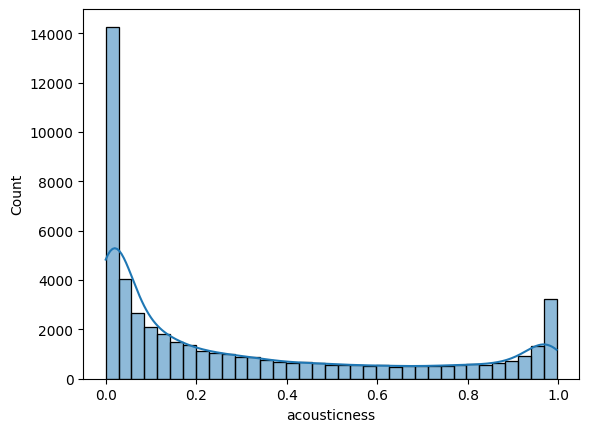

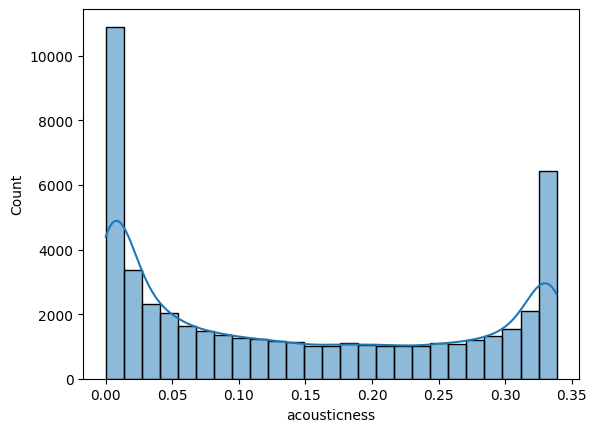

   popularity  acousticness  danceability  duration_ms    energy  \
0   -1.108003     -1.115222      0.524878    -0.154369  1.289876   
1   -0.850633     -1.052978      0.356933    -0.239968  1.097101   
2   -1.043661     -1.128000      0.345737    -0.265269  0.586813   
3   -0.657606     -0.957758      1.207853    -0.725393  0.378918   
4   -0.786291     -1.115458      0.446504    -0.201488 -0.048212   

   instrumentalness  key  liveness  loudness  speechiness     tempo   valence  \
0          1.875809    1 -0.488113  0.638132    -0.185322 -0.655420  1.225073   
1          2.361357    5 -0.432433  0.339248    -0.627258 -0.170027  0.302431   
2         -0.521812   11  2.104140  0.732892    -0.582867  0.276811 -0.498812   
3         -0.550300    4 -0.228269  0.752201     1.434452  0.277499 -0.753752   
4          2.235361    9 -0.228269  0.465324    -0.515787  0.862942 -0.539278   

   music_genre  mode_Minor  
0            5           1  
1            5           1  
2            5   

In [5]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
import seaborn as sns
from scipy.stats import boxcox

#load data
df = pd.read_csv("musicData.csv")
df.drop(['track_name', 'artist_name','instance_id','obtained_date'], axis=1, inplace=True)
print(df.shape)

# Handle missing values
df['tempo'].replace('?', np.nan, inplace=True)
df['duration_ms'].replace(-1, np.nan, inplace=True)
imputer = SimpleImputer(strategy='median')
df[['duration_ms', 'tempo']] = imputer.fit_transform(df[['duration_ms', 'tempo']])
df.dropna(inplace=True)
print("Shape after dropping:", df.shape)

# Transform string format key into numerical data
le = LabelEncoder()
df['key'] = le.fit_transform(df['key'])

#dummy code "mode"
dummy_mode = pd.get_dummies(df['mode'], prefix='mode', drop_first=True)
df = pd.concat([df, dummy_mode], axis=1)
df.drop(['mode'], axis=1, inplace=True)

# Transform genre category labels into numerical labels
genres = df['music_genre'].unique()
df['music_genre'] = pd.Categorical(df['music_genre'])
df['music_genre'] = df['music_genre'].cat.codes

#acousticness
sns.histplot(df['acousticness'], kde=True)
plt.show()

df['acousticness'] = boxcox(df['acousticness'] + 1)[0]
sns.histplot(df['acousticness'], kde=True)
plt.show()

#scale numerical values
continuous_predictors = ['popularity', 'acousticness', 'danceability','duration_ms', 'energy','instrumentalness', 'liveness', 'loudness', 'speechiness', 'tempo', 'valence']
scaler = StandardScaler()
df[continuous_predictors] = scaler.fit_transform(df[continuous_predictors])
print(df.head())

##Train/Test split

In [9]:
genres = df['music_genre'].unique()
train_data = pd.DataFrame()
test_data = pd.DataFrame()
for genre in genres:
    genre_data = df[df['music_genre'] == genre]
    train_genre, test_genre = train_test_split(genre_data, test_size=500, random_state=42)
    train_data = pd.concat([train_data, train_genre])
    test_data = pd.concat([test_data, test_genre])

X_train = train_data.drop('music_genre', axis = 1)
y_train = train_data['music_genre']
X_test = test_data.drop('music_genre', axis = 1)
y_test = test_data['music_genre']

print(X_test.shape)
print(y_test.shape)
print(X_train.shape)
print(y_train.shape)

(5000, 13)
(5000,)
(45000, 13)
(45000,)


##Dimensionality Reduction

###LDA

Explained variance ratio: [0.63833066 0.16998138 0.11372898]


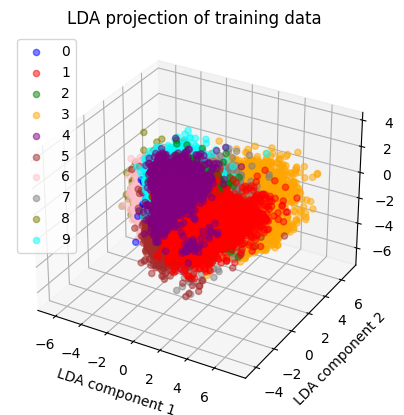

In [7]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

lda = LinearDiscriminantAnalysis(n_components=3)
lda.fit(X_train, y_train)

X_train_lda = lda.transform(X_train)
print("Explained variance ratio:", lda.explained_variance_ratio_)

X_test_lda = lda.transform(X_test)
colors = ['blue', 'red', 'green', 'orange', 'purple', 'brown', 'pink', 'gray', 'olive', 'cyan']
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

for i, color in zip(range(len(y_train.unique())), colors):
    ax.scatter(X_train_lda[y_train == i, 0], X_train_lda[y_train == i, 1], X_train_lda[y_train == i, 2], 
               c=color, label=i, alpha=0.5)
    
ax.set_xlabel('LDA component 1')
ax.set_ylabel('LDA component 2')
ax.set_zlabel('LDA component 3')
ax.legend(loc='best')
ax.set_title('LDA projection of training data')

plt.show()

###PCA

####2D

['Electronic' 'Anime' 'Jazz' 'Alternative' 'Country' 'Rap' 'Blues' 'Rock'
 'Classical' 'Hip-Hop']


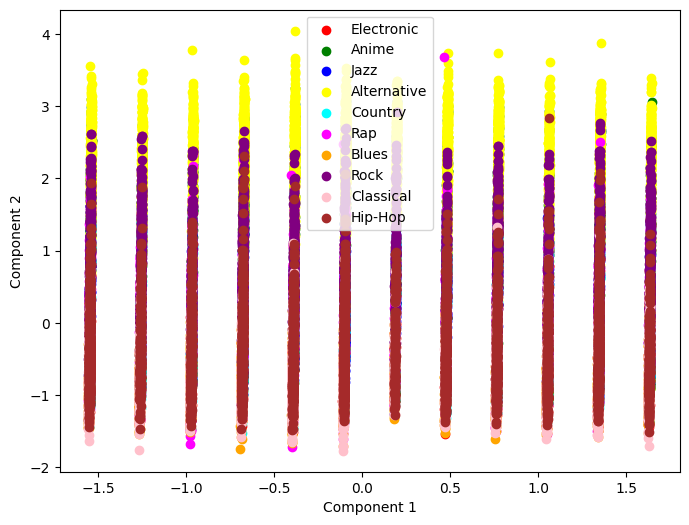

In [ ]:
pca_2d = PCA(n_components=2, whiten=True)
pca_2d.fit(X_train)
X_train_pca_2d = pca_2d.transform(X_train)
X_test_pca_2d = pca_2d.transform(X_test)

target_names = genres
print(target_names)
target_ids = range(len(target_names))
plt.figure(figsize=(8, 6))
for i, c, label in zip(target_ids, colors, target_names):
    plt.scatter(X_train_pca_2d[y_train == i, 0], X_train_pca_2d[y_train == i, 1], c=c, label=label)

plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.legend()
plt.show()

####3D

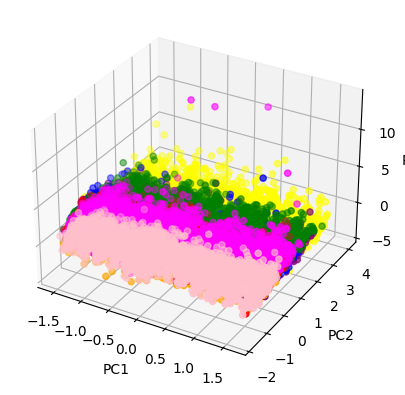

Variance explained by each principal component: [0.51537739 0.15403364 0.05987442]
Variance explained in total: 0.7292854434622553


In [ ]:
pca_3d = PCA(n_components=3, whiten=True)
pca_3d.fit(X_train)
X_train_pca_3d = pca_3d.transform(X_train)
X_test_pca_3d = pca_3d.transform(X_test)

target_names = genres
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
for i, c, label in zip(target_ids, colors, target_names):
    ax.scatter(X_train_pca_3d[y_train == i, 0], X_train_pca_3d[y_train == i, 1], X_train_pca_3d[y_train == i, 2],c=c, label=label)

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
plt.show()

# Calculate the variance explained by each principal component
variance_explained_3d = pca_3d.explained_variance_ratio_
total_variance_explained_3d = 0
for i in variance_explained_3d:
  total_variance_explained_3d += i
print('Variance explained by each principal component:', variance_explained_3d)
print('Variance explained in total:', total_variance_explained_3d )

####5D

In [ ]:
pca_5d = PCA(n_components=5, whiten=True)
pca_5d.fit(X_train)
X_train_pca_5d = pca_5d.transform(X_train)
X_test_pca_5d = pca_5d.transform(X_test)

# Calculate the variance explained by each principal component
variance_explained_5d = pca_5d.explained_variance_ratio_
total_variance_explained_5d = 0
for i in variance_explained_5d:
  total_variance_explained_5d += i
print('Variance explained by each principal component in 5D:', variance_explained_5d)
print('Variance explained in total:', total_variance_explained_5d)

Variance explained by each principal component in 5D: [0.51537739 0.15403364 0.05987442 0.0454146  0.04217488]
Variance explained in total: 0.8168749224042217


####6D

In [ ]:
pca_6d = PCA(n_components=6, whiten=True)
pca_6d.fit(X_train)
X_train_pca_6d = pca_6d.transform(X_train)
X_test_pca_6d = pca_6d.transform(X_test)

# Calculate the variance explained by each principal component
variance_explained_6d = pca_6d.explained_variance_ratio_
total_variance_explained_6d = 0
for i in variance_explained_6d:
  total_variance_explained_6d += i
print('Variance explained by each principal component in 6D:', variance_explained_6d)
print('Variance explained in total:', total_variance_explained_6d)

Variance explained by each principal component in 6D: [0.51537739 0.15403364 0.05987442 0.0454146  0.04217488 0.04099283]
Variance explained in total: 0.857867747476041


In [ ]:
feature_names = X_train.columns

loadings = pca_6d.components_
for i in range(len(loadings)):
    loading_values = loadings[i]
    sorted_loading_values = sorted(zip(feature_names, loading_values), key=lambda x: abs(x[1]), reverse=True)
    print(f"PC {i+1}:")
    for feature in sorted_loading_values:
        print(f"\t{feature[0]}: {feature[1]}")


PC 1:
	key: 0.9999347541656399
	mode_Minor: -0.00793183526599963
	danceability: -0.005984896762907959
	speechiness: -0.0035479172380533837
	acousticness: 0.002566207619833196
	popularity: -0.0017365368142702488
	loudness: -0.0017136319494188128
	tempo: -0.0016883626632793229
	instrumentalness: 0.0011322170896544276
	energy: -0.0011038811358919567
	duration_ms: -0.0008573744882231457
	valence: -0.000664466142841204
	liveness: 0.00031864566425500234
PC 2:
	loudness: -0.46398587913309275
	energy: -0.4471370471135815
	acousticness: 0.38957116411613124
	instrumentalness: 0.3419719341030069
	danceability: -0.30352923213718724
	valence: -0.28109458816250305
	popularity: -0.25287632190330056
	speechiness: -0.17819499125104282
	tempo: -0.15439603858099282
	duration_ms: 0.13243019886058524
	liveness: -0.08839239514252718
	key: -0.005890956555798063
	mode_Minor: -0.0026841960469487346
PC 3:
	danceability: -0.4527285484993509
	popularity: -0.3627526722037277
	duration_ms: 0.35384081139739754
	temp

####7D

In [ ]:
pca_7d = PCA(n_components=7, whiten=True)
pca_7d.fit(X_train)
X_train_pca_7d = pca_7d.transform(X_train)
X_test_pca_7d = pca_7d.transform(X_test)

# Calculate the variance explained by each principal component
variance_explained_7d = pca_7d.explained_variance_ratio_
total_variance_explained_7d = 0
for i in variance_explained_7d:
  total_variance_explained_7d += i
print('Variance explained by each principal component in 7D:', variance_explained_7d)
print('Variance explained in total:', total_variance_explained_7d)

Variance explained by each principal component in 7D: [0.51537739 0.15403364 0.05987442 0.0454146  0.04217488 0.04099283
 0.03581088]
Variance explained in total: 0.8936786289570735


###t-SNE after 2D PCA

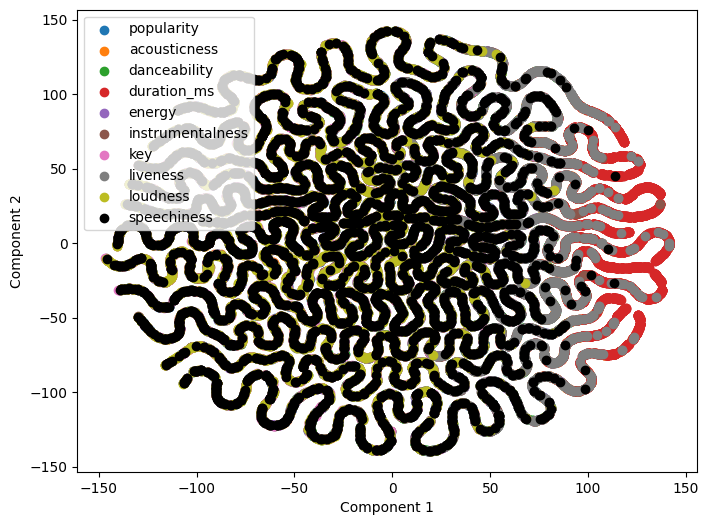

In [ ]:
X_train_tsne = TSNE(n_components=2, perplexity=20, n_jobs=-1).fit_transform(X_train_pca_2d)
X_train_tsne.shape

target_names = df.columns
target_ids = range(len(target_names))
plt.figure(figsize=(8, 6))
for i, c, label in zip(target_ids, colors, target_names):
    plt.scatter(X_train_tsne[y_train == i, 0], X_train_tsne[y_train == i, 1], c=c, label=label)

plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.legend()
plt.show()

##Kmeans

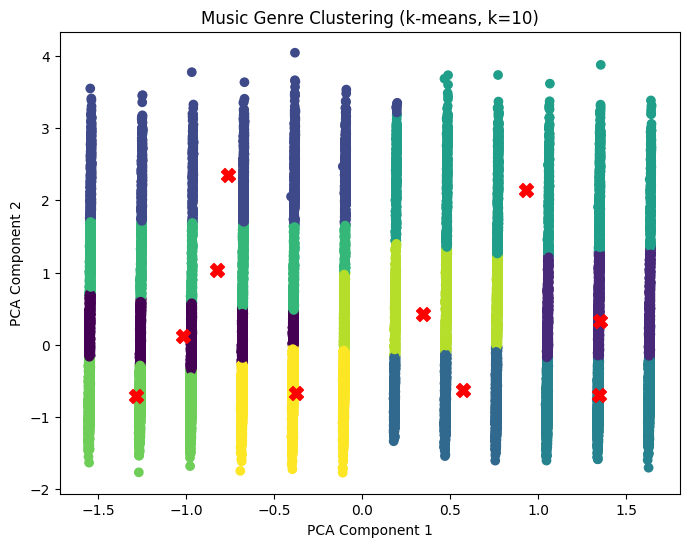

Total sum of distances to cluster centers: 18239.7341370768


In [ ]:
#Kmeans using PCA
best_num = 10
kmeans = cluster.KMeans(n_clusters=best_num, n_init='auto')
cluster_labels = kmeans.fit_predict(X_train_pca_2d)

plt.figure(figsize=(8, 6))
plt.scatter(X_train_pca_2d[:, 0], X_train_pca_2d[:, 1], c=cluster_labels)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], marker='X', s=100, color='red')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('Music Genre Clustering (k-means, k={})'.format(best_num))
plt.show()

total_distance = sum(kmeans.transform(X_train_pca_2d).min(axis=1))
print("Total sum of distances to cluster centers:", total_distance)

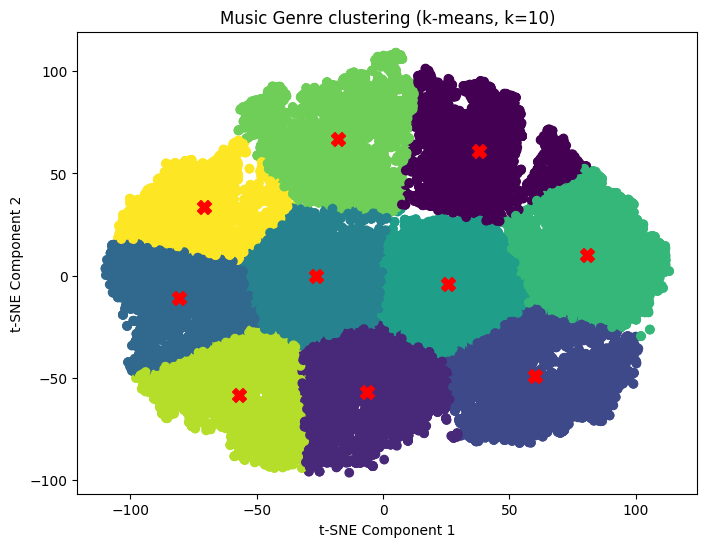

Total sum of distances to cluster centers: 978283.528639317


In [ ]:
#Kmeans using t_sne
best_num = 10
kmeans = cluster.KMeans(n_clusters=best_num, n_init='auto')
cluster_labels = kmeans.fit_predict(X_train_tsne)

plt.figure(figsize=(8, 6))
plt.scatter(X_train_tsne[:, 0], X_train_tsne[:, 1], c=cluster_labels)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], marker='X', s=100, color='red')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.title('Music Genre clustering (k-means, k={})'.format(best_num))
plt.show()

total_distance = sum(kmeans.transform(X_train_tsne).min(axis=1))
print("Total sum of distances to cluster centers:", total_distance)

##Random Forest Model

###LDA

In [8]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=1000, max_samples=1.0, max_features=0.01,bootstrap=True, criterion='gini')
rf.fit(X_train_lda,y_train)

RandomForestClassifier(max_features=0.01, max_samples=1.0, n_estimators=1000)

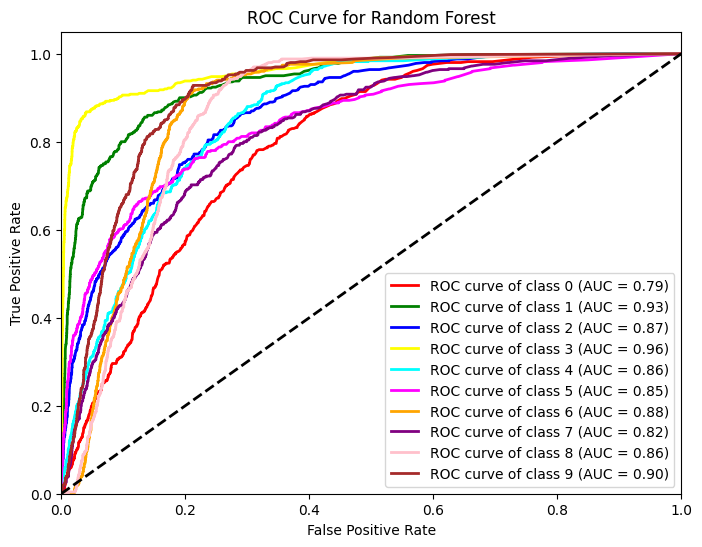

Weighted AUC is: 0.8732442888888889


In [9]:
from sklearn.metrics import roc_curve, auc
y_pred = rf.predict(X_test_lda)
y_pred_proba = rf.predict_proba(X_test_lda)

auc_scores = []
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(10):
    fpr[i], tpr[i], _ = roc_curve(y_test == i, y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    auc_scores.append(roc_auc[i])

plt.figure(figsize=(8, 6))
colors = ['red', 'green', 'blue', 'yellow', 'cyan', 'magenta', 'orange', 'purple', 'pink', 'brown']
for i, color in zip(range(10), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label='ROC curve of class {0} (AUC = {1:0.2f})'
             ''.format(i, roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Random Forest')
plt.legend(loc="lower right")
plt.show()

n_samples = 500
n_classes = 10
total_samples = 5000

class_weights = np.array([n_samples/total_samples]*n_classes)
weighted_auc = np.sum(class_weights * auc_scores)
print("Weighted AUC is:", weighted_auc)

###using pca 6d

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=1000, max_samples=1.0, max_features=0.01,bootstrap=True, criterion='gini')
rf.fit(X_train_pca_6d,y_train)

RandomForestClassifier(max_features=0.01, max_samples=1.0, n_estimators=1000)

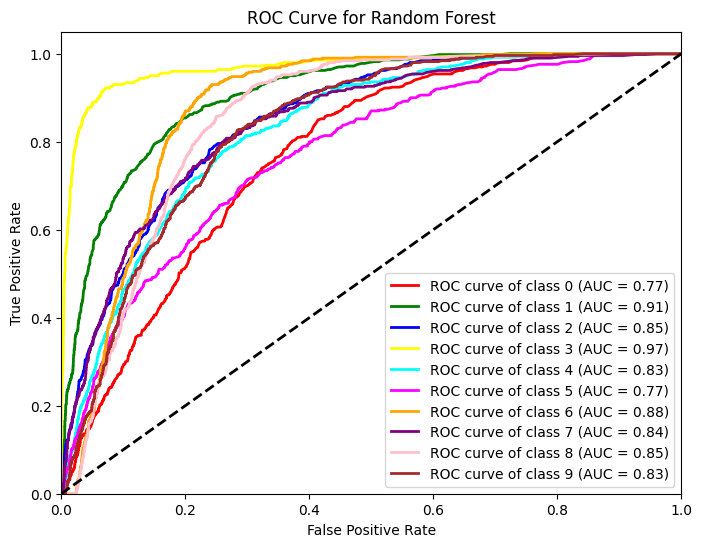

Weighted AUC is: 0.8488236444444445


In [ ]:
from sklearn.metrics import roc_curve, auc
y_pred = rf.predict(X_test_pca_6d)
y_pred_proba = rf.predict_proba(X_test_pca_6d)

auc_scores = []
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(10):
    fpr[i], tpr[i], _ = roc_curve(y_test == i, y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    auc_scores.append(roc_auc[i])

plt.figure(figsize=(8, 6))
colors = ['red', 'green', 'blue', 'yellow', 'cyan', 'magenta', 'orange', 'purple', 'pink', 'brown']
for i, color in zip(range(10), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label='ROC curve of class {0} (AUC = {1:0.2f})'
             ''.format(i, roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Random Forest')
plt.legend(loc="lower right")
plt.show()

n_samples = 500
n_classes = 10
total_samples = 5000

class_weights = np.array([n_samples/total_samples]*n_classes)
weighted_auc = np.sum(class_weights * auc_scores)
print("Weighted AUC is:", weighted_auc)

In [ ]:
print(X_train_pca_6d)
feature_names = ['feature_{}'.format(i) for i in range(1, X_train_pca_6d.shape[1]+1)]
X_train_df = pd.DataFrame(X_train_pca_6d, columns=feature_names)

importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

for i in range(X_train_pca_6d.shape[1]):
    print(f"{i+1}. {feature_names[indices[i]]} ({importances[indices[i]]})")

[[ 0.76679226  0.12741246  1.28099984 -0.4957993   0.49230113  0.25383103]
 [-0.39624231 -1.2092038   0.87755868  0.74358017 -0.50100693 -0.15444908]
 [ 0.76381291 -0.06670037 -0.05101141  0.08806721 -0.32419244  0.81165465]
 ...
 [-0.39572299 -0.38067217 -0.87855446  2.11026109  0.53800763 -0.97769322]
 [-0.11025789 -1.18473514 -1.17528114  4.16556411 -2.50720563 -1.07531439]
 [ 0.47398307 -0.22671227 -1.56874138  0.27872992  0.33759884 -0.80840854]]
1. feature_2 (0.22303130604606758)
2. feature_3 (0.17752531296338045)
3. feature_4 (0.1637231610414018)
4. feature_5 (0.15601939182192737)
5. feature_6 (0.1425127266452127)
6. feature_1 (0.13718810148200997)


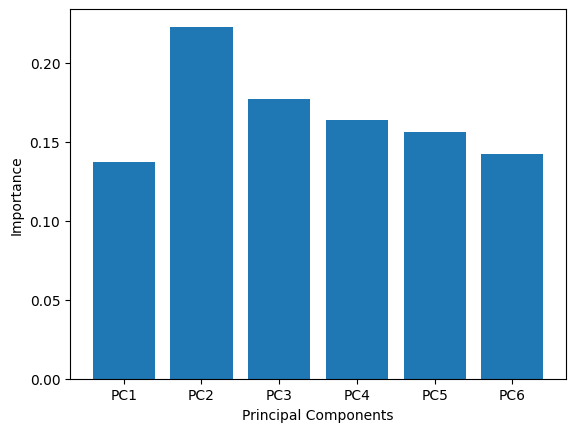

In [ ]:
importances = rf.feature_importances_

# Plot feature importances
plt.bar(range(X_train_pca_6d.shape[1]), importances)
plt.xticks(range(X_train_pca_6d.shape[1]), ['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6'])
plt.xlabel('Principal Components')
plt.ylabel('Importance')
plt.show()


###using 2d t-sne data

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=1000, max_samples=1.0, max_features=0.01,bootstrap=True, criterion='gini')
rf.fit(X_train_tsne,y_train)

RandomForestClassifier(max_features=0.01, max_samples=1.0, n_estimators=1000)

AUC score for class 0: 0.567
AUC score for class 1: 0.487
AUC score for class 2: 0.435
AUC score for class 3: 0.612
AUC score for class 4: 0.471
AUC score for class 5: 0.524
AUC score for class 6: 0.628
AUC score for class 7: 0.543
AUC score for class 8: 0.660
AUC score for class 9: 0.517


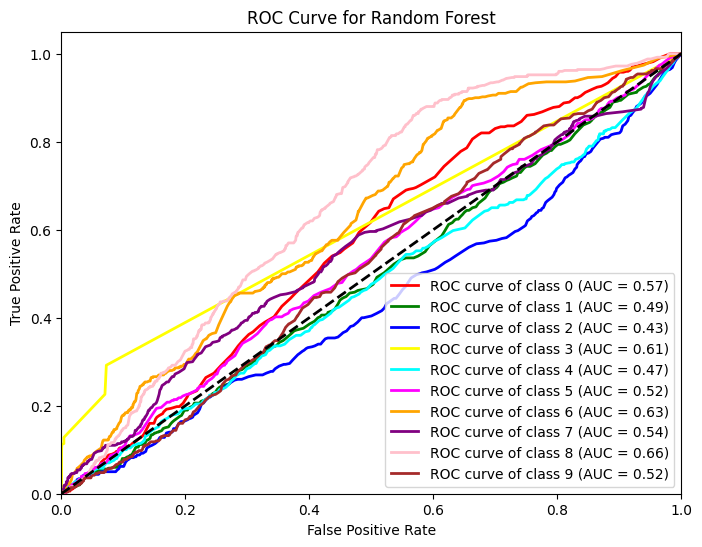

In [ ]:
from sklearn.metrics import roc_curve, auc
y_pred = rf.predict(X_test_pca_2d)
y_pred_proba = rf.predict_proba(X_test_pca_2d)

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(10):
    fpr[i], tpr[i], _ = roc_curve(y_test == i, y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    print(f"AUC score for class {i}: {roc_auc[i]:.3f}")

plt.figure(figsize=(8, 6))
colors = ['red', 'green', 'blue', 'yellow', 'cyan', 'magenta', 'orange', 'purple', 'pink', 'brown']
for i, color in zip(range(10), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label='ROC curve of class {0} (AUC = {1:0.2f})'
             ''.format(i, roc_auc[i]))
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Random Forest')
plt.legend(loc="lower right")
plt.show()

##SVM

###LDA

In [10]:
from sklearn import svm
from sklearn.svm import LinearSVC
from sklearn.svm import SVC
from sklearn import metrics

svm = LinearSVC(dual = False) 
svm.fit(X_train_lda, y_train)

LinearSVC(dual=False)

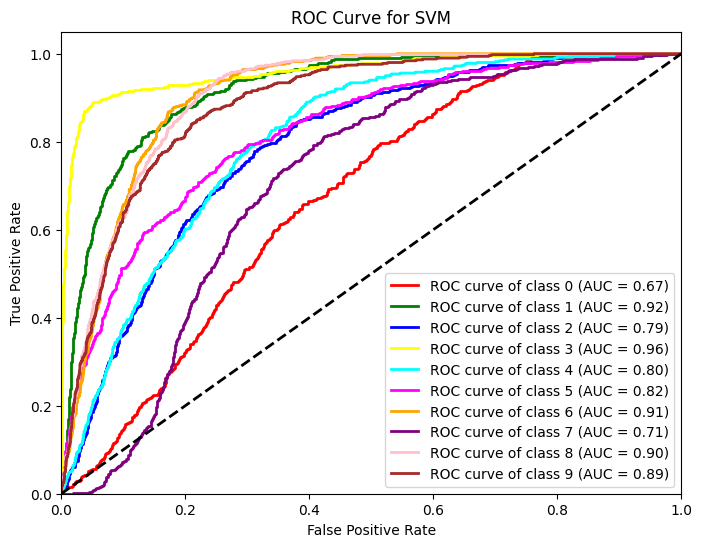

Weighted AUC is: 0.8366950222222224


In [11]:
y_score = svm.decision_function(X_test_lda)

# Convert distances to probabilities using the sigmoid function
y_score = 1 / (1 + np.exp(-y_score))

# Compute the ROC curve and AUC score for each class
auc_scores = []
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(10):
    fpr[i], tpr[i], _ = roc_curve(y_test == i, y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    auc_scores.append(roc_auc[i])

# Plot the ROC curves for each class
plt.figure(figsize=(8, 6))
colors = ['red', 'green', 'blue', 'yellow', 'cyan', 'magenta', 'orange', 'purple', 'pink', 'brown']
for i, color in zip(range(10), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label='ROC curve of class {0} (AUC = {1:0.2f})'
             ''.format(i, roc_auc[i]))
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for SVM')
plt.legend(loc="lower right")
plt.show()

n_samples = 500
n_classes = 10
total_samples = 5000

class_weights = np.array([n_samples/total_samples]*n_classes)
weighted_auc = np.sum(class_weights * auc_scores)
print("Weighted AUC is:", weighted_auc)

###PCA

In [ ]:
from sklearn import svm
from sklearn.svm import LinearSVC
from sklearn.svm import SVC
from sklearn import metrics

svm = LinearSVC(dual = False) 
svm.fit(X_train_pca_6d, y_train)

LinearSVC(dual=False)

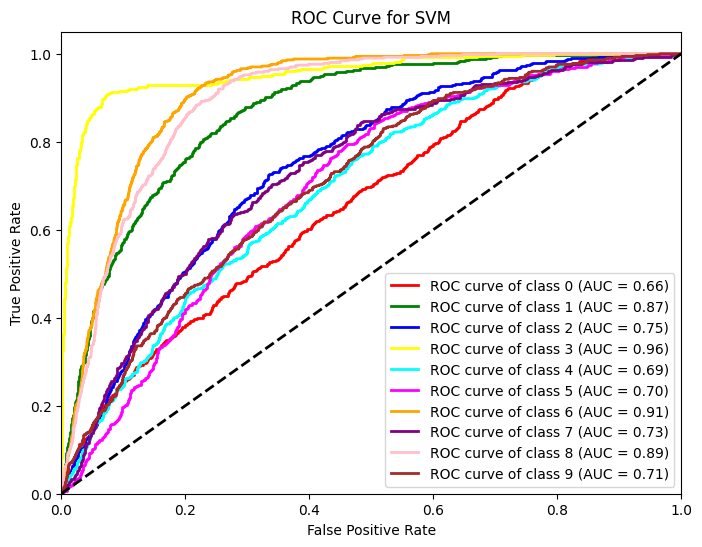

Weighted AUC is: 0.7865887555555556


In [ ]:
y_score = svm.decision_function(X_test_pca_6d)

# Convert distances to probabilities using the sigmoid function
y_score = 1 / (1 + np.exp(-y_score))

# Compute the ROC curve and AUC score for each class
auc_scores = []
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(10):
    fpr[i], tpr[i], _ = roc_curve(y_test == i, y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    auc_scores.append(roc_auc[i])

# Plot the ROC curves for each class
plt.figure(figsize=(8, 6))
colors = ['red', 'green', 'blue', 'yellow', 'cyan', 'magenta', 'orange', 'purple', 'pink', 'brown']
for i, color in zip(range(10), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label='ROC curve of class {0} (AUC = {1:0.2f})'
             ''.format(i, roc_auc[i]))
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for SVM')
plt.legend(loc="lower right")
plt.show()

n_samples = 500
n_classes = 10
total_samples = 5000

class_weights = np.array([n_samples/total_samples]*n_classes)
weighted_auc = np.sum(class_weights * auc_scores)
print("Weighted AUC is:", weighted_auc)

##Neural Network using LDA

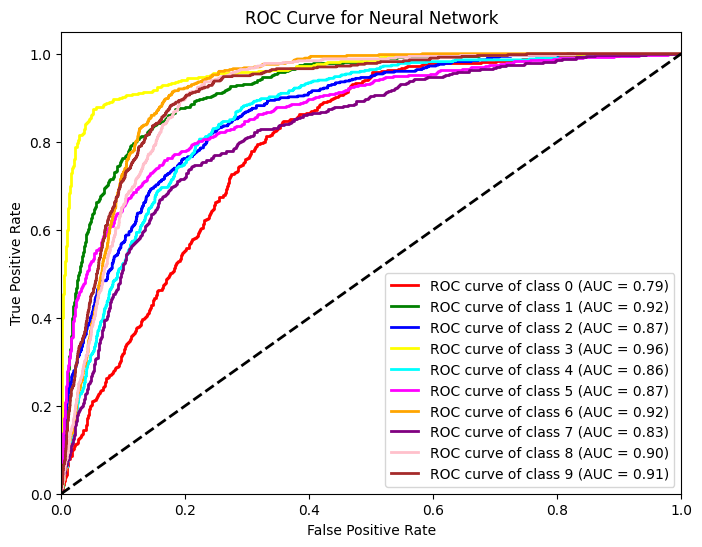

Weighted AUC: 0.8827363333333335


In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# Convert the data to PyTorch tensors
X_train, X_test = torch.FloatTensor(X_train_lda), torch.FloatTensor(X_test_lda)
y_train, y_test = torch.LongTensor(np.array(y_train)), torch.LongTensor(np.array(y_test))
y_train, y_test = torch.reshape(y_train, (-1,)), torch.reshape(y_test, (-1,))


# Define the neural network model
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.fc1 = nn.Linear(X_train_lda.shape[1], 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 10)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# Create the neural network object and optimizer
net = Net()
optimizer = optim.Adam(net.parameters(), lr=0.001)

# Define the loss function
criterion = nn.CrossEntropyLoss()


# Train the neural network
for epoch in range(100):
    optimizer.zero_grad()
    output = net(X_train)
    loss = criterion(output, y_train)
    loss.backward()
    optimizer.step()

# Evaluate the neural network on the test data
with torch.no_grad():
    output = net(X_test)
    y_score = torch.softmax(output, dim=1).numpy()

# Compute the ROC curve and AUC score for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
auc_scores=[]

for i in range(10):
    fpr[i], tpr[i], _ = roc_curve(y_test == i, y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    auc_scores.append(roc_auc[i])
    
# Plot the ROC curves for each class
plt.figure(figsize=(8, 6))
colors = ['red', 'green', 'blue', 'yellow', 'cyan', 'magenta', 'orange', 'purple', 'pink', 'brown']
for i, color in zip(range(10), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label='ROC curve of class {0} (AUC = {1:0.2f})'
             ''.format(i, roc_auc[i]))
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Neural Network')
plt.legend(loc="lower right")
plt.show()

n_samples = 500
n_classes = 10
total_samples = 5000

class_weights = np.array([n_samples/total_samples]*n_classes)
weighted_auc = np.sum(class_weights * auc_scores)
print("Weighted AUC:", weighted_auc)

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# Define the neural network model
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.fc1 = nn.Linear(X_train_lda.shape[1], 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 10)

    def forward(self, x):
        x = torch.sigmoid(self.fc1(x))
        x = torch.sigmoid(self.fc2(x))
        x = self.fc3(x)
        return x

# Create the neural network object and optimizer
net = Net()
optimizer = optim.Adam(net.parameters(), lr=0.001)

# Define the loss function
criterion = nn.CrossEntropyLoss()

# Convert the data to PyTorch tensors
X_train, X_test = torch.FloatTensor(X_train_lda), torch.FloatTensor(X_test_lda)
y_train, y_test = torch.LongTensor(np.array(y_train)), torch.LongTensor(np.array(y_test))
y_train, y_test = torch.reshape(y_train, (-1,)), torch.reshape(y_test, (-1,))


# Train the neural network
for epoch in range(20):
    optimizer.zero_grad()
    output = net(X_train)
    loss = criterion(output, y_train)
    loss.backward()
    optimizer.step()

# Evaluate the neural network on the test data
with torch.no_grad():
    output = net(X_test)
    y_score = torch.softmax(output, dim=1).numpy()

# Compute the ROC curve and AUC score for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
auc_scores =[]

for i in range(10):
    fpr[i], tpr[i], _ = roc_curve(y_test == i, y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    auc_scores.append(roc_auc[i])
# Plot the ROC curves for each class
plt.figure(figsize=(8, 6))
colors = ['red', 'green', 'blue', 'yellow', 'cyan', 'magenta', 'orange', 'purple', 'pink', 'brown']
for i, color in zip(range(10), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label='ROC curve of class {0} (AUC = {1:0.2f})'
             ''.format(i, roc_auc[i]))
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Neural Network')
plt.legend(loc="lower right")
plt.show()

n_samples = 500
n_classes = 10
total_samples = 5000

class_weights = np.array([n_samples/total_samples]*n_classes)
weighted_auc = np.sum(class_weights * auc_scores)
print("Weighted AUC:", weighted_auc)


NameError: ignored

##Neural Network using x_pca

In [ ]:
X_train, X_val = torch.FloatTensor(X_train_pca_6d), torch.FloatTensor(X_test_pca_6d)
y_train, y_val = torch.LongTensor(np.array(y_train)), torch.LongTensor(np.array(y_test))
y_train, y_val = torch.reshape(y_train, (-1,)), torch.reshape(y_val, (-1,))
train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

test_dataset = TensorDataset(X_val, y_val)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=True)
print(y_train.shape, y_val)
print(X_train.shape, X_val)

torch.Size([45000]) tensor([5, 5, 5,  ..., 6, 6, 6])
torch.Size([45000, 6]) tensor([[ 7.6084e-01, -6.2646e-01,  1.7402e+00,  2.5186e+00,  1.6446e-01,
         -1.6353e+00],
        [-6.7941e-01,  1.7007e-01,  3.1349e-01,  4.7235e-01,  1.6931e-01,
          3.7111e-01],
        [ 4.7725e-01,  1.9349e-01,  1.6958e+00, -2.5964e-01,  7.8383e-01,
         -3.9283e-01],
        ...,
        [-6.8225e-01, -1.4452e-03, -1.8274e+00, -3.2937e-01,  8.1128e-02,
          7.3259e-02],
        [-1.2595e+00, -5.8749e-01, -3.9728e-01,  3.0864e+00, -3.4361e+00,
          7.4611e-01],
        [-3.9430e-01, -1.0838e+00, -9.5634e-02,  3.2244e+00, -1.7396e+00,
          1.7058e+00]])


In [ ]:
# Build neural network for predicting Diabetes
class NN(nn.Module):
    def __init__(self, input_size, n_hidden, output_size, n_layers=1, act=None):
        super(NN, self).__init__()
        self.input_size = input_size
        self.n_layers = n_layers
        self.D = nn.Linear(input_size, n_hidden)
        self.H = nn.Linear(n_hidden, n_hidden)
        self.C = nn.Linear(n_hidden, output_size)
        self.act = act
        self.ReLU = nn.ReLU()
        self.Sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = x.view(-1, self.input_size)
        out = self.D(x)
        if self.act == "ReLU":
            out = self.ReLU(out)
        elif self.act == "Sigmoid":
            out = self.Sigmoid(out)

        for i in range(1, self.n_layers):
            out = self.H(out)
            if self.act == "ReLU":
                out = self.ReLU(out)
            elif self.act == "Sigmoid":
                out = self.Sigmoid(out)
        return self.C(out)

# Create train and test func
def train(epoch, model, criterion):
    model.train()
    train_loss = 0
    for batch_idx, (data, target) in enumerate(train_loader):
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target.long().squeeze())
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    return train_loss / len(train_loader.dataset)


def test(model, criterion, model_name):
    model.eval()
    test_loss = 0
    correct = 0
    with torch.no_grad():
        vals = []
        preds = []
        probs = []
        for data, target in test_loader:
            output = model(data)
            test_loss += criterion(output, target).item()  # sum up batch loss
            _, pred = torch.max(output.data, 1)
            correct += pred.eq(target.data.view_as(pred)).cpu().sum().item()
            prob = torch.softmax(output, dim=1)[:, 1]
            vals.extend(target.numpy())
            preds.extend(pred.numpy())
            probs.extend(prob.numpy())

        fpr, tpr, _ = roc_curve(vals, probs)
        auc = roc_auc_score(vals, probs, multi_class='ovr')
        print("The AUC of the model is: {}\n".format(auc))

def test(model, criterion, model_name):
    model.eval()
    test_loss = 0
    correct = 0
    with torch.no_grad():
        vals = []
        preds = []
        probs = []
        for data, target in test_loader:
            output = model(data)
            test_loss += criterion(output, target).item()  # sum up batch loss
            _, pred = torch.max(output.data, 1)
            correct += pred.eq(target.data.view_as(pred)).cpu().sum().item()
            prob = torch.softmax(output, dim=1)
            vals.extend(target.numpy())
            preds.extend(pred.numpy())
            probs.extend(prob.numpy()[:, 1])  # use class 1 probabilities for ROC AUC

        auc = roc_auc_score(vals, probs, multi_class='ovr')
        print("The multi-class AUC of the model is: {}\n".format(auc))



In [ ]:
learning_rate = 1e-2
lambda_l2 = 1e-3
num_epochs = 100

input_size, output_size = 6, 10
hidden_ls = [32]
activ_func = [None, "ReLU", "Sigmoid"]

criterion = nn.CrossEntropyLoss(reduction='sum')

# Training the networks

for act in activ_func:
    for hidden_num in range(1, 4):
        for h in hidden_ls:
            model = NN(input_size, h, output_size, hidden_num, act)
            print('Activation function: {}, Hidden Layer: {}'
                  .format(act, hidden_num))

            optimizer = optim.Adam(model.parameters(), lr=learning_rate)
            train_losses = []
            for epoch in range(num_epochs+1):
                epoch_loss = train(epoch, model, criterion=criterion)
                train_losses.append(epoch_loss)
                if epoch % 100 == 0:
                    print("Epoch: {}/{}, training loss: {}".format(epoch, num_epochs, epoch_loss))

            #test(model, criterion=criterion, model_name='Activation function: {}, hidden={}, num_hidden={}'
                 #.format(act, h, hidden_num))


Activation function: None, Hidden Layer: 1
Epoch: 0/100, training loss: 1.834108659532335
Epoch: 100/100, training loss: 1.8128824695163304
Activation function: None, Hidden Layer: 2
Epoch: 0/100, training loss: 1.839314796702067
Epoch: 100/100, training loss: 1.8146675906923082
Activation function: None, Hidden Layer: 3
Epoch: 0/100, training loss: 1.8434328771591186
Epoch: 100/100, training loss: 1.8158011419508193
Activation function: ReLU, Hidden Layer: 1
Epoch: 0/100, training loss: 1.7884805941263835
Epoch: 100/100, training loss: 1.7497461571163602
Activation function: ReLU, Hidden Layer: 2
Epoch: 0/100, training loss: 1.791239199595981
Epoch: 100/100, training loss: 1.7524472848892212
Activation function: ReLU, Hidden Layer: 3
Epoch: 0/100, training loss: 1.7976721127827961
Epoch: 100/100, training loss: 1.7546168116675482
Activation function: Sigmoid, Hidden Layer: 1
Epoch: 0/100, training loss: 1.8420810379452175
Epoch: 100/100, training loss: 1.7438246904585097
Activation fu

###reLu

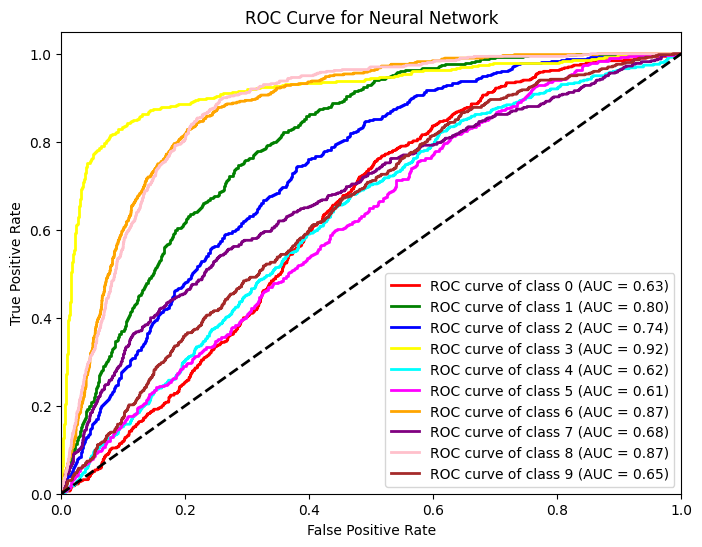

Weighted AUC: 0.7401115777777778


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# Convert the data to PyTorch tensors
X_train, X_test = torch.FloatTensor(X_train_pca_6d), torch.FloatTensor(X_test_pca_6d)
y_train, y_test = torch.LongTensor(np.array(y_train)), torch.LongTensor(np.array(y_test))
y_train, y_test = torch.reshape(y_train, (-1,)), torch.reshape(y_test, (-1,))


# Define the neural network model
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.fc1 = nn.Linear(X_train_pca_6d.shape[1], 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 10)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# Create the neural network object and optimizer
net = Net()
optimizer = optim.Adam(net.parameters(), lr=0.001)

# Define the loss function
criterion = nn.CrossEntropyLoss()


# Train the neural network
for epoch in range(20):
    optimizer.zero_grad()
    output = net(X_train)
    loss = criterion(output, y_train)
    loss.backward()
    optimizer.step()

# Evaluate the neural network on the test data
with torch.no_grad():
    output = net(X_test)
    y_score = torch.softmax(output, dim=1).numpy()

# Compute the ROC curve and AUC score for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
auc_scores=[]

for i in range(10):
    fpr[i], tpr[i], _ = roc_curve(y_test == i, y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    auc_scores.append(roc_auc[i])
    
# Plot the ROC curves for each class
plt.figure(figsize=(8, 6))
colors = ['red', 'green', 'blue', 'yellow', 'cyan', 'magenta', 'orange', 'purple', 'pink', 'brown']
for i, color in zip(range(10), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label='ROC curve of class {0} (AUC = {1:0.2f})'
             ''.format(i, roc_auc[i]))
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Neural Network')
plt.legend(loc="lower right")
plt.show()

n_samples = 500
n_classes = 10
total_samples = 5000

class_weights = np.array([n_samples/total_samples]*n_classes)
weighted_auc = np.sum(class_weights * auc_scores)
print("Weighted AUC:", weighted_auc)

###Sigmoid

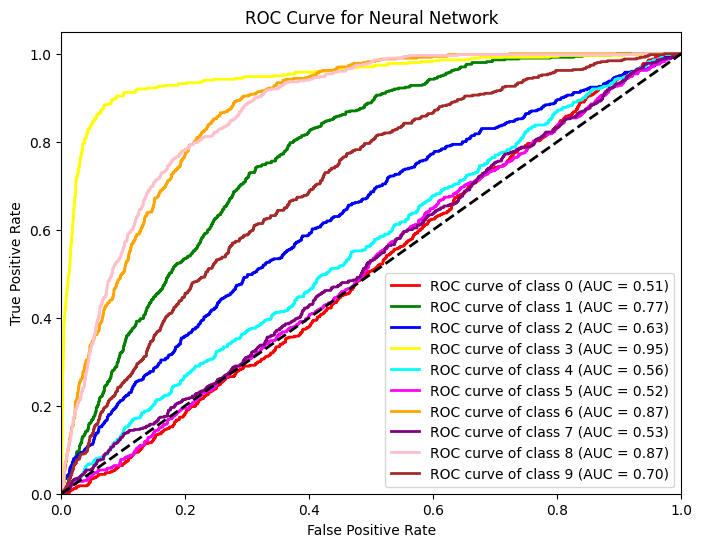

Weighted AUC: 0.6903406222222223


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# Define the neural network model
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.fc1 = nn.Linear(X_train_pca_6d.shape[1], 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 10)

    def forward(self, x):
        x = torch.sigmoid(self.fc1(x))
        x = torch.sigmoid(self.fc2(x))
        x = self.fc3(x)
        return x

# Create the neural network object and optimizer
net = Net()
optimizer = optim.Adam(net.parameters(), lr=0.001)

# Define the loss function
criterion = nn.CrossEntropyLoss()

# Convert the data to PyTorch tensors
X_train, X_test = torch.FloatTensor(X_train_pca_6d), torch.FloatTensor(X_test_pca_6d)
y_train, y_test = torch.LongTensor(np.array(y_train)), torch.LongTensor(np.array(y_test))
y_train, y_test = torch.reshape(y_train, (-1,)), torch.reshape(y_test, (-1,))


# Train the neural network
for epoch in range(20):
    optimizer.zero_grad()
    output = net(X_train)
    loss = criterion(output, y_train)
    loss.backward()
    optimizer.step()

# Evaluate the neural network on the test data
with torch.no_grad():
    output = net(X_test)
    y_score = torch.softmax(output, dim=1).numpy()

# Compute the ROC curve and AUC score for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
auc_scores =[]

for i in range(10):
    fpr[i], tpr[i], _ = roc_curve(y_test == i, y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    auc_scores.append(roc_auc[i])
# Plot the ROC curves for each class
plt.figure(figsize=(8, 6))
colors = ['red', 'green', 'blue', 'yellow', 'cyan', 'magenta', 'orange', 'purple', 'pink', 'brown']
for i, color in zip(range(10), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label='ROC curve of class {0} (AUC = {1:0.2f})'
             ''.format(i, roc_auc[i]))
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Neural Network')
plt.legend(loc="lower right")
plt.show()

n_samples = 500
n_classes = 10
total_samples = 5000

class_weights = np.array([n_samples/total_samples]*n_classes)
weighted_auc = np.sum(class_weights * auc_scores)
print("Weighted AUC:", weighted_auc)


##Extra

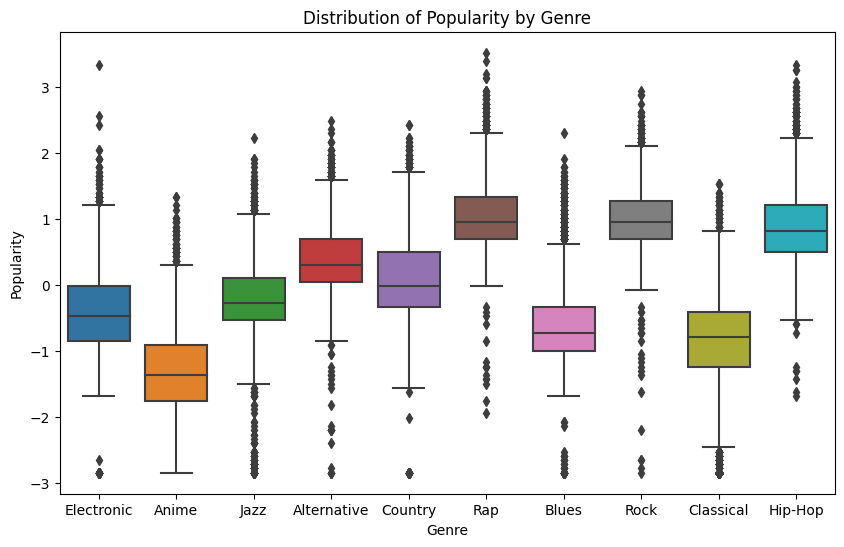

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from scipy.stats import boxcox

#load data
df = pd.read_csv("musicData.csv")
df.drop(['track_name', 'artist_name','instance_id','obtained_date'], axis=1, inplace=True)

# Handle missing values
df['tempo'].replace('?', np.nan, inplace=True)
df['duration_ms'].replace(-1, np.nan, inplace=True)
imputer = SimpleImputer(strategy='median')
df[['duration_ms', 'tempo']] = imputer.fit_transform(df[['duration_ms', 'tempo']])
df.dropna(inplace=True)

# Transform string format key into numerical data
le = LabelEncoder()
df['key'] = le.fit_transform(df['key'])

#dummy code "mode"
dummy_mode = pd.get_dummies(df['mode'], prefix='mode', drop_first=True)
df = pd.concat([df, dummy_mode], axis=1)
df.drop(['mode'], axis=1, inplace=True)

#acousticness
df['acousticness'] = boxcox(df['acousticness'] + 1)[0]

#scale numerical values
continuous_predictors = ['popularity', 'acousticness', 'danceability','duration_ms', 'energy','instrumentalness', 'liveness', 'loudness', 'speechiness', 'tempo', 'valence']
scaler = StandardScaler()
df[continuous_predictors] = scaler.fit_transform(df[continuous_predictors])

genres = df['music_genre'].unique()
plt.figure(figsize=(10,6))
sns.boxplot(x='music_genre', y='popularity', data=df)
plt.title('Distribution of Popularity by Genre')
plt.xlabel('Genre')
plt.ylabel('Popularity')
plt.show()

/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


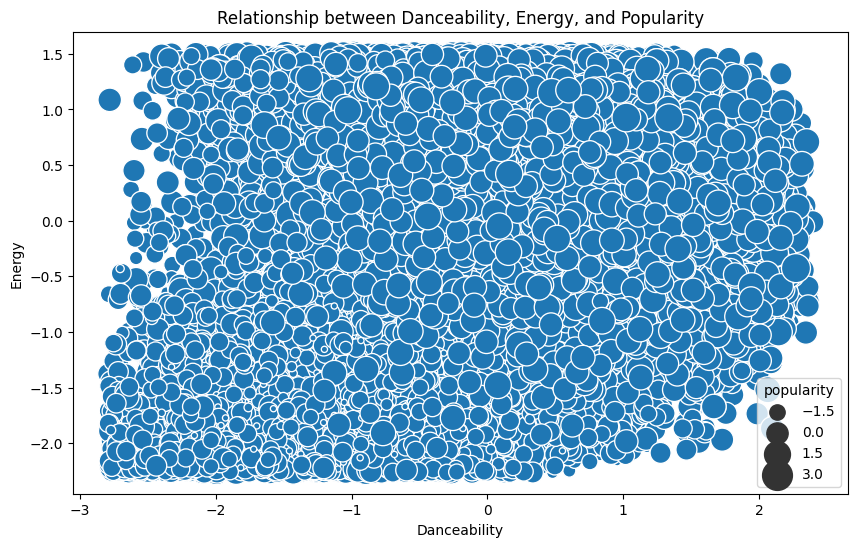

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.scatterplot(x='danceability', y='energy', size='popularity', sizes=(20, 500), data=df)
plt.title('Relationship between Danceability, Energy, and Popularity')
plt.xlabel('Danceability')
plt.ylabel('Energy')
plt.show()